In [13]:
# Active l'affichage des graphiques directement dans le notebook
# %matplotlib inline  # (souvent déjà activé par défaut dans Jupyter)

# Masque les warnings pour éviter d'encombrer le notebook pendant l'exécution
import warnings; warnings.filterwarnings("ignore")

# Import des bibliothèques principales utilisées dans la modélisation
import numpy as np              # Calcul numérique (vecteurs, matrices)
import pandas as pd             # Manipulation des données (DataFrame)
import matplotlib.pyplot as plt # Visualisation des graphiques

# Gestion des chemins de fichiers (robuste pour toute plateforme)
from pathlib import Path

# Chargement et sauvegarde de modèles et objets Python
import json, joblib

In [14]:
# Chemin vers le modèle final sauvegardé (RandomForest dans notre cas).
# Si XGBoost devient le meilleur modèle, il faudra changer ce nom.
MODEL_PATH = "models/RandomForest_house21.joblib"

# Chemin vers le fichier JSON contenant les métadonnées du modèle :
# - le nom du modèle choisi
# - l’horizon de prédiction
# - la liste des features utilisées
META_PATH  = "models/model_meta_house21.json"

# Chemin vers le fichier de données propres produit dans le Notebook 1
DATA_PATH  = "data/processed/House_21_1min_clean.csv"

# Chargement du modèle entraîné (RandomForest ou XGBoost)
model = joblib.load(MODEL_PATH)

# Chargement des métadonnées (structure du modèle)
meta  = json.load(open(META_PATH))

# Extraction des informations utiles :
best_name   = meta["model"]          # nom du meilleur modèle choisi
H           = int(meta["horizon_min"])   # horizon de prédiction (en minutes)
feature_set = meta["features"]       # liste complète des features utilisées

# Affichage d’un résumé pour vérifier que nous avons bien chargé le bon modèle
print(f"Modèle chargé : {best_name} | Horizon = {H} min")
print(f"{len(feature_set)} features attendues.")

Modèle chargé : RandomForest | Horizon = 10 min
51 features attendues.


In [15]:
# Chargement du fichier de données propres (produit dans le Notebook 1).
# - On parse la colonne "Time" en datetime
# - On définit "Time" comme index (important pour le resampling)
# - On trie l'index pour garantir l'ordre chronologique
df = (pd.read_csv(DATA_PATH, parse_dates=["Time"], index_col="Time")
        .sort_index())

# Affiche :
# - le nombre total de lignes et colonnes
# - la première et la dernière date de la série temporelle
print(df.shape, df.index.min(), "→", df.index.max())

# Visualise les 3 premières lignes pour vérifier que tout est correct
df.head(3)

# Définition d'une période d’analyse fixe pour les tests / visualisations
# Ici : du 1er au 7 avril 2015 (modifiable librement selon besoin)
start = "2015-04-01"
end   = "2015-04-07"

# On extrait un sous-ensemble du dataset sur cette période
part  = df.loc[start:end].copy()

# Affiche le nombre de lignes de la période choisie + les dates exactes couvertes
print(part.shape, part.index.min(), "→", part.index.max())

(705337, 11) 2014-03-07 16:20:00 → 2015-07-10 11:56:00
(10080, 11) 2015-04-01 00:00:00 → 2015-04-07 23:59:00


In [16]:
# La variable que nous voulons prédire : la puissance totale consommée
TARGET = "Aggregate"

def build_features(frame: pd.DataFrame, horizon_min: int, feat_list=None):
    # On travaille sur une copie du dataframe pour éviter de modifier l’original
    X = frame.copy()

    # --- 3.1 Création des caractéristiques temporelles
    # Heure (0–23)
    X["hour"]       = X.index.hour
    # Jour de la semaine (0 = lundi, 6 = dimanche)
    X["dow"]        = X.index.dayofweek
    # Mois de l’année (1–12)
    X["month"]      = X.index.month
    # Indicateur binaire : 1 si samedi/dimanche, sinon 0
    X["is_weekend"] = (X["dow"] >= 5).astype(int)

    # Encodage cyclique de l’heure et du jour (évite la discontinuité 23→0)
    X["hour_sin"] = np.sin(2*np.pi*X["hour"]/24)
    X["hour_cos"] = np.cos(2*np.pi*X["hour"]/24)
    X["dow_sin"]  = np.sin(2*np.pi*X["dow"]/7)
    X["dow_cos"]  = np.cos(2*np.pi*X["dow"]/7)

    # --- 3.2 Lags : valeurs passées de la consommation (1 à 60 minutes avant)
    # Ces variables sont essentielles en séries temporelles
    for k in range(1, 61):
        X[f"agg_lag_{k}"] = X[TARGET].shift(k)

    # --- 3.3 Fenêtres glissantes (rolling) identiques au Notebook 2
    # Moyennes et écarts-types des dernières minutes
    X["agg_rollmean_5"]   = X[TARGET].shift(1).rolling(5,  min_periods=3).mean()
    X["agg_rollstd_5"]    = X[TARGET].shift(1).rolling(5,  min_periods=3).std()
    X["agg_rollmean_15"]  = X[TARGET].shift(1).rolling(15, min_periods=5).mean()
    X["agg_rollmean_60"]  = X[TARGET].shift(1).rolling(60, min_periods=10).mean()

    # --- 3.4 Colonnes d’appareils (si existantes)
    # Dans House 21 il y a Appliance1, Appliance2, etc.
    appliance_cols = [c for c in frame.columns if c.lower().startswith("appliance")]
    # Elles sont déjà dans X, donc rien à ajouter ici

    # --- 3.5 Création de la cible décalée : valeur d'Aggregate dans H minutes
    # Utile pour comparer le vrai vs prédit sur la période choisie
    X["target"] = X[TARGET].shift(-horizon_min)

    # --- 3.6 Sélection finale des features
    # On utilise la liste provenant du fichier meta pour garantir la compatibilité modèle ↔ interface
    if feat_list is None:
        feat_list = feature_set

    # On enlève les lignes où il manque des valeurs (causées par les shifts/rolling)
    XY = X[feat_list + ["target"]].dropna()

    # Retourne un X prêt pour la prédiction + le y vrai pour la comparaison
    return XY[feat_list], XY["target"]

# Application de la fonction sur la période sélectionnée
X_feats, y_true = build_features(part, H, feature_set)

# Affiche les dimensions des features et de la cible
X_feats.shape, y_true.shape

((10040, 51), (10040,))

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 150 out of 150 | elapsed:    0.0s finished


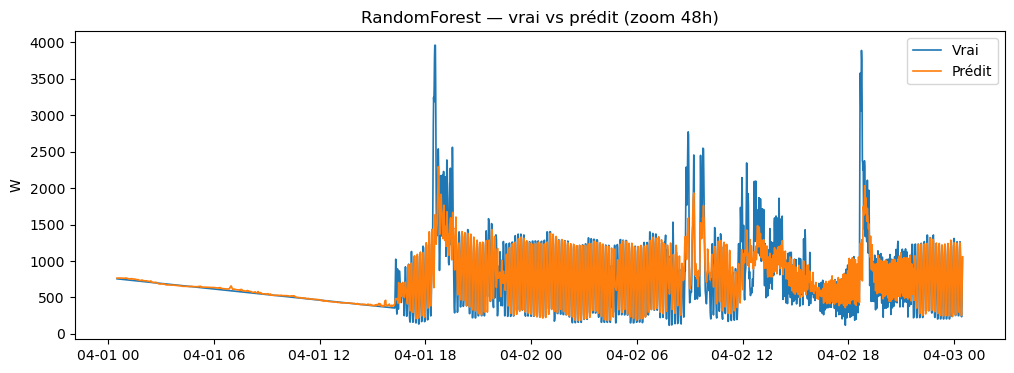

In [17]:
# Génère les prédictions du modèle sur les features préparées
# On convertit les prédictions en Series pour garder l’index datetime
y_pred = pd.Series(model.predict(X_feats), index=X_feats.index, name="pred")


# --- Définition d'une fonction pour visualiser vrai vs prédit sur 48h ---
def plot_true_pred(y_true, y_pred, title="Vrai vs prédit (zoom)"):
    # Sélectionne environ 48h de données (2 jours * 24h * 60 minutes)
    idx = y_true.index[:2*24*60]  
    
    # Création de la figure
    plt.figure(figsize=(12,4))
    
    # Courbe de la consommation réelle
    plt.plot(idx, y_true.loc[idx], label="Vrai", lw=1.2)
    
    # Courbe des prédictions du modèle
    plt.plot(idx, y_pred.loc[idx], label="Prédit", lw=1.2)
    
    # Mise en forme du graphique
    plt.title(title)
    plt.ylabel("W")
    plt.legend()
    plt.show()


# Affiche le graphique pour les 48 premières heures de la période analysée
plot_true_pred(y_true, y_pred, title=f"{best_name} — vrai vs prédit (zoom 48h)")

Énergie vraie  : 218.53 kWh
Énergie prédite: 198.13 kWh


,kWh_vrai,kWh_prédit
Time,,
2015-04-01,16.083107,15.831622
2015-04-02,19.889122,19.710600
2015-04-03,34.335647,32.116748
2015-04-04,36.752636,30.476876
2015-04-05,38.717274,35.524077


Heures au-dessus du 90e percentile : 1004 min (≈ 16.7 h)
Charge de base ~ p10 : 450 W


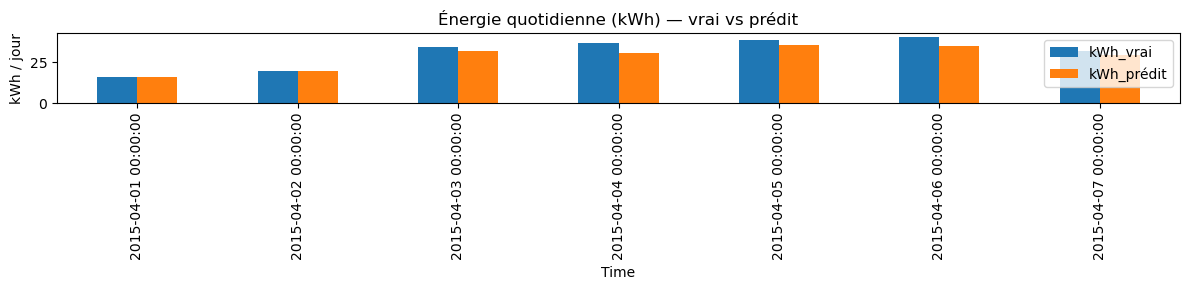

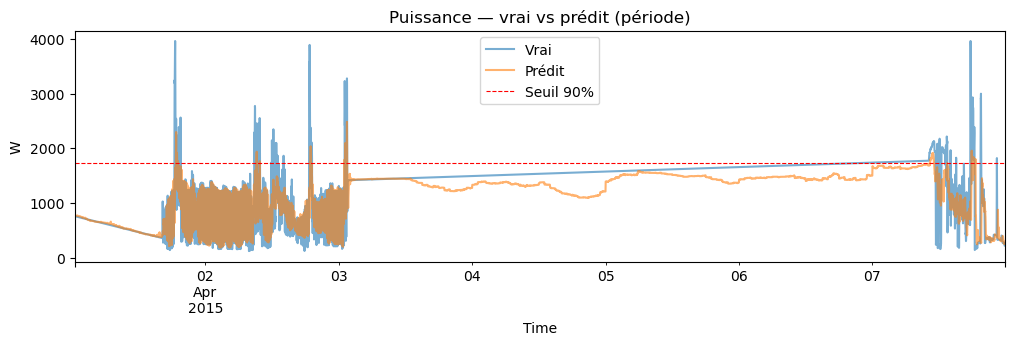

In [18]:
# --- Conversion de la puissance (W) en énergie (kWh) sur la période analysée ---
def power_to_kwh(series_w):
    # La puissance est enregistrée chaque minute en Watts.
    # Conversion : somme des W-minute → kWh = somme / (1000*60)
    return series_w.sum() / (1000*60)

# Calcul de l’énergie réelle et prédite pour la période
kwh_true = power_to_kwh(y_true)
kwh_pred = power_to_kwh(y_pred)

print(f"Énergie vraie  : {kwh_true:.2f} kWh")
print(f"Énergie prédite: {kwh_pred:.2f} kWh")


# --- Calcul des KPI journaliers en kWh ---
# On regroupe les valeurs minute par minute par jour, puis on convertit en kWh
daily = pd.DataFrame({"true": y_true, "pred": y_pred}).resample("D").sum() / (1000*60)

# Renommage des colonnes pour plus de clarté
daily.columns = ["kWh_vrai", "kWh_prédit"]

display(daily.head())


# --- Analyse des heures de pointe ---
# Calcul du 90e percentile de la puissance → seuil des fortes consommations
p90 = y_true.quantile(0.90)

# Nombre de minutes où la consommation dépasse ce seuil
peak_hours = (y_true > p90).sum()

print(f"Heures au-dessus du 90e percentile : {peak_hours} min (≈ {peak_hours/60:.1f} h)")


# --- Calcul de la charge de base ---
# Le 10e percentile représente la consommation minimale typique du logement
p10 = y_true.quantile(0.10)
print(f"Charge de base ~ p10 : {p10:.0f} W")


# --- Visualisation : Energie quotidienne ---
daily.plot(kind="bar", figsize=(12,3), title="Énergie quotidienne (kWh) — vrai vs prédit")
plt.ylabel("kWh / jour")
plt.tight_layout()
plt.show()


# --- Visualisation : Puissance minute par minute sur la période ---
plt.figure(figsize=(12,3))

# Courbe réelle et prédite
y_true.plot(alpha=0.6, label="Vrai")
y_pred.plot(alpha=0.6, label="Prédit")

# Ligne horizontale représentant le seuil des heures de pointe
plt.axhline(p90, color="r", ls="--", lw=0.8, label="Seuil 90%")

plt.title("Puissance — vrai vs prédit (période)")
plt.ylabel("W")
plt.legend()
plt.show()

In [19]:
tips = []   # Liste dans laquelle on va stocker toutes les recommandations finales


# --- 1) Analyse des pics de consommation ---
# Si plus de 5% des minutes de la période sont au-dessus du seuil "pic" (p90),
# alors on conseille d'étaler l'utilisation des appareils énergivores.
if peak_hours > (0.05 * len(y_true)):  # > 5% du temps en pic
    tips.append(
        "Réduire les pics : étaler l’usage des gros appareils (lave-linge, chauffe-eau) hors heures pleines."
    )


# --- 2) Analyse de la consommation minimale (charge de base) ---
# Si le niveau minimal typique (p10) est supérieur à 250 W,
# cela indique que plusieurs appareils tournent en permanence → veilles, équipements anciens, etc.
if p10 > 250:
    tips.append(
        "La charge de base est élevée (>250 W) : identifier les veilles (routeur, box TV, frigo ancien)."
    )


# --- 3) Comparaison énergie vraie vs énergie prédite ---
# On regarde si le modèle sous-estime ou surestime de manière significative (>5%).
gap_kwh = kwh_true - kwh_pred
if abs(gap_kwh) > 0.05 * kwh_true:
    tips.append(
        "Le modèle sous/surestime un peu l’énergie totale : vérifiez les jours inhabituels (visites, météo)."
    )


# --- 4) Jours les plus énergivores ---
# On récupère les 3 jours où la consommation en kWh est la plus élevée.
top_days = daily.sort_values("kWh_vrai", ascending=False).head(3)
tips.append(
    "Jours les plus énergivores : " + ", ".join(top_days.index.strftime("%Y-%m-%d").tolist())
)


# --- Affichage final des recommandations ---
print(" RECOMMANDATIONS")
for t in tips:
    print("•", t)

 RECOMMANDATIONS
• Réduire les pics : étaler l’usage des gros appareils (lave-linge, chauffe-eau) hors heures pleines.
• La charge de base est élevée (>250 W) : identifier les veilles (routeur, box TV, frigo ancien).
• Le modèle sous/surestime un peu l’énergie totale : vérifiez les jours inhabituels (visites, météo).
• Jours les plus énergivores : 2015-04-06, 2015-04-05, 2015-04-04


In [20]:
# Crée le dossier "reports" s'il n'existe pas encore
Path("reports").mkdir(exist_ok=True)


# --- 1) Export du CSV minute par minute ---
# On rassemble les valeurs vraies et les valeurs prédites dans un seul tableau (colonnes true / pred)
out = pd.concat({"true": y_true, "pred": y_pred}, axis=1)

# On enregistre ce tableau dans un fichier CSV pour pouvoir le visualiser ou l’utiliser ailleurs
out.to_csv("reports/predictions_house21_period.csv")


# --- 2) Export des indicateurs journaliers ---
# Le tableau "daily" contient l’énergie vraie et prédite (en kWh) pour chaque jour de la période
daily.to_csv("reports/daily_kwh_house21_period.csv")


# --- 3) Confirmation des fichiers générés ---
print(" Exports :")
print("• reports/predictions_house21_period.csv")
print("• reports/daily_kwh_house21_period.csv")

 Exports :
• reports/predictions_house21_period.csv
• reports/daily_kwh_house21_period.csv


In [21]:
!pip install streamlit -q

In [22]:
import streamlit as st
print("✅ Streamlit est bien installé :", st.__version__)

✅ Streamlit est bien installé : 1.51.0
